# Checks finales post-training

Validación de los modelos de **producción** antes de servir la API:

| # | Check | Qué mide |
|---|-------|----------|
| **1** | Sanity check modelos finales | Errores en test con `temas-phase4` + `carga-phase3` |
| **2** | Antes/después temas | Fase 1 (solo título) vs Fase 4 (sección+título) |
| **5** | Regresión por clase | F1 por tema: ¿mejoró cada clase o alguna empeoró? |

> Reiniciá el kernel si editaste código del proyecto recientemente.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "config.yml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import importlib
import mindful_news.training.data as _data
import mindful_news.training.preprocess as _preprocess

importlib.reload(_preprocess)
importlib.reload(_data)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

import importlib
import json

import mindful_news.training.evaluate as _evaluate
importlib.reload(_evaluate)

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score

from mindful_news.training.evaluate import _default_model_dir, predict_test_errors

FINAL_MODELS = {
    "temas": ROOT / "models" / "temas-phase4",
    "carga": ROOT / "models" / "carga-phase3",
}
BASELINE_TEMAS = ROOT / "models" / "temas"

for task, path in FINAL_MODELS.items():
    assert path.exists(), f"Modelo final no encontrado: {path}"
print("Modelos finales OK")


c:\Users\arihs\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Modelos finales OK


## Check 1 — Sanity check modelos finales

In [2]:
results_final = {}
summary_rows = []

for task, model_dir in FINAL_MODELS.items():
    frame = predict_test_errors(task, model_dir=model_dir)
    results_final[task] = frame
    errors = (~frame["correct"]).sum()
    acc = frame["correct"].mean()
    summary_rows.append(
        {
            "task": task,
            "model": str(model_dir),
            "n_test": len(frame),
            "errors": errors,
            "error_rate": 1 - acc,
            "accuracy": acc,
        }
    )
    print(f"{task}: {errors}/{len(frame)} errores ({1-acc:.1%})")

pd.DataFrame(summary_rows)


c:\Users\arihs\anaconda3\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: C:\Users\arihs\anaconda3\Lib\site-packages\torchvision\image.pyd'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

temas: 409/1801 errores (22.7%)


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

carga: 372/1801 errores (20.7%)


,task,model,n_test,errors,error_rate,accuracy
0,temas,c:\Users\arihs\Code\mlprod-obligatorio\models\...,1801,409,0.227096,0.772904
1,carga,c:\Users\arihs\Code\mlprod-obligatorio\models\...,1801,372,0.206552,0.793448


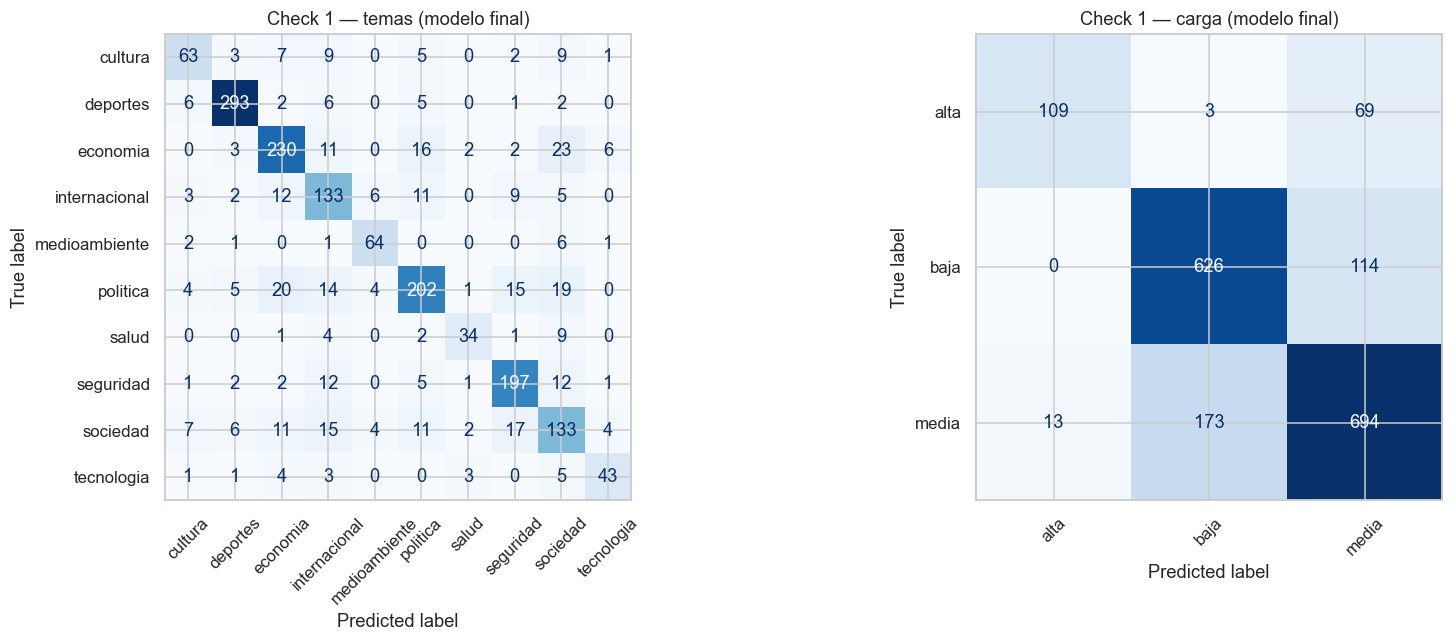

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, task in zip(axes, FINAL_MODELS):
    frame = results_final[task]
    labels = sorted(frame["true_label"].unique())
    cm = confusion_matrix(frame["true_label"], frame["pred_label"], labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(f"Check 1 — {task} (modelo final)")

plt.tight_layout()
plt.show()


In [4]:
def top_confusion_pairs(frame: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    errors = frame[~frame["correct"]]
    return (
        errors.groupby(["true_label", "pred_label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(n)
    )


for task in FINAL_MODELS:
    print(f"\n=== {task.upper()} — pares de confusión (final) ===")
    display(top_confusion_pairs(results_final[task]))



=== TEMAS — pares de confusión (final) ===


,true_label,pred_label,count
18,economia,sociedad,23
34,politica,economia,20
39,politica,sociedad,19
60,sociedad,seguridad,17
15,economia,politica,16
56,sociedad,internacional,15
38,politica,seguridad,15
35,politica,internacional,14



=== CARGA — pares de confusión (final) ===


,true_label,pred_label,count
4,media,baja,173
2,baja,media,114
1,alta,media,69
3,media,alta,13
0,alta,baja,3


In [5]:
# Export errores test (modelos finales)
out = ROOT / "data" / "exports" / "test_errors_final.csv"
combined = []
for task, frame in results_final.items():
    part = frame[~frame["correct"]].copy()
    part.insert(0, "task", task)
    combined.append(part)
export_df = pd.concat(combined, ignore_index=True)
export_df.to_csv(out, index=False)
print(f"Exportado: {out} ({len(export_df)} filas)")
export_df.head(5)


Exportado: c:\Users\arihs\Code\mlprod-obligatorio\data\exports\test_errors_final.csv (781 filas)


,task,id,titulo,seccion,input_text,tema,label,split_date,medio,url,true_label,pred_label,confidence,correct,carga
0,temas,14747,Hungría reactiva la marcha del Orgullo LGBT en...,espana,espana | Hungría reactiva la marcha del Orgull...,sociedad,9,2026-06-01 12:39:00,El Observador,https://www.elobservador.com.uy/espana/sucede/...,sociedad,internacional,0.999997,False,NaN
1,temas,14438,Reventa mundialista: piden fortunas por palcos...,espana,espana | Reventa mundialista: piden fortunas p...,economia,2,2026-06-04 09:10:00,El Observador,https://www.elobservador.com.uy/espana/economi...,economia,deportes,0.999997,False,NaN
2,temas,1637,"Parlamento aprueba Uruguay Impulsa, programa c...",informacion,informacion | Parlamento aprueba Uruguay Impul...,politica,0,2026-06-03 17:41:17,El País,https://www.elpais.com.uy/informacion/politica...,politica,economia,0.999992,False,NaN
3,temas,15373,"Inteligencia artificial, sensores y diagnóstic...",brand-studio,"brand-studio | Inteligencia artificial, sensor...",tecnologia,6,2026-05-29 05:00:00,El Observador,https://www.elobservador.com.uy/brand-studio/i...,tecnologia,salud,0.999991,False,NaN
4,temas,9078,Uruguay recibirá el Pabellón Nacional de manos...,deporte,deporte | Uruguay recibirá el Pabellón Naciona...,sociedad,9,2026-06-03 21:34:27,La Diaria,https://ladiaria.com.uy/deporte/articulo/2026/...,sociedad,deportes,0.999991,False,NaN


## Check 2 — Antes/después: temas fase 1 vs fase 4

In [6]:
assert BASELINE_TEMAS.exists(), f"Baseline no encontrado: {BASELINE_TEMAS}"

temas_baseline = predict_test_errors("temas", model_dir=BASELINE_TEMAS)
temas_phase4 = results_final["temas"]

for label, frame in [("Fase 1 (solo título)", temas_baseline), ("Fase 4 (sección+título)", temas_phase4)]:
    err = (~frame["correct"]).sum()
    print(f"{label}: {err}/{len(frame)} errores | acc={frame['correct'].mean():.3f}")

# Filas donde cambió la predicción entre modelos
merged = temas_baseline[["titulo", "seccion", "true_label", "pred_label", "confidence"]].rename(
    columns={"pred_label": "pred_f1", "confidence": "conf_f1"}
)
merged = merged.merge(
    temas_phase4[["titulo", "pred_label", "confidence", "correct"]].rename(
        columns={"pred_label": "pred_f4", "confidence": "conf_f4", "correct": "correct_f4"}
    ),
    on="titulo",
)
merged["pred_f1_correct"] = merged["true_label"] == merged["pred_f1"]
merged["changed_pred"] = merged["pred_f1"] != merged["pred_f4"]
merged["fixed"] = (~merged["pred_f1_correct"]) & merged["correct_f4"]
merged["broken"] = merged["pred_f1_correct"] & (~merged["correct_f4"])

print(f"\nPredicciones distintas: {merged['changed_pred'].sum()}")
print(f"Corregidos (mal en f1, bien en f4): {merged['fixed'].sum()}")
print(f"Empeorados (bien en f1, mal en f4): {merged['broken'].sum()}")


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Fase 1 (solo título): 444/1801 errores | acc=0.753
Fase 4 (sección+título): 409/1801 errores | acc=0.773

Predicciones distintas: 311
Corregidos (mal en f1, bien en f4): 137
Empeorados (bien en f1, mal en f4): 108


In [7]:
# Ejemplos corregidos y empeorados
cols = ["true_label", "pred_f1", "pred_f4", "seccion", "titulo"]

print("=== Corregidos por fase 4 (muestra) ===")
display(merged[merged["fixed"]][cols].head(10))

print("\n=== Empeorados por fase 4 (muestra) ===")
display(merged[merged["broken"]][cols].head(10))


=== Corregidos por fase 4 (muestra) ===


,true_label,pred_f1,pred_f4,seccion,titulo
20,politica,internacional,politica,espana,La corrupción arrincona a Pedro Sánchez: la Gu...
31,tecnologia,economia,tecnologia,que-hay-detras-la-alianza-bbva-y-la-nueva-empr...,Qué hay detrás de la alianza entre BBVA y la n...
33,politica,internacional,politica,espana,Los socios de Pedro Sánchez exigen elecciones ...
37,politica,internacional,politica,argentina,Milei contra Milei: el sueño de la reelección ...
38,politica,sociedad,politica,nacional,Préstamos millonarios para Montevideo: Bergara...
49,internacional,deportes,internacional,mundo,colombia hacia el balotaje la campana se empan...
54,internacional,salud,internacional,Estados Unidos,El plan de Washington ante la emergencia de la...
58,internacional,economia,internacional,nacional,"Mercosur plantea su ""gran preocupación"" por me..."
60,politica,internacional,politica,argentina,Karina Milei armó una foto con Patricia Bullri...
64,politica,economia,politica,economia-y-empresas,Choque político en directorio de la ANP por dr...



=== Empeorados por fase 4 (muestra) ===


,true_label,pred_f1,pred_f4,seccion,titulo
1111,internacional,internacional,seguridad,espana,Giro en la causa del hermano de Pedro Sánchez:...
1214,tecnologia,tecnologia,sociedad,opinion,Notas sobre la nueva _smart city_ uruguaya
1217,internacional,internacional,politica,espana,Ocho años de Pedro Sánchez: inestabilidad pres...
1218,economia,economia,sociedad,economia-y-empresas,Un dormitorio: el nuevo rey de la Vivienda Pro...
1233,seguridad,seguridad,internacional,"Noticias, Internacionales",El “karma” de un uruguayo que cayó preso en Ve...
1242,seguridad,seguridad,deportes,"Noticias, Policiales",Peñarol suspendió práctica de niños por un tir...
1288,economia,economia,sociedad,agro,El hito que cumple 150 años y es motivo del Dí...
1326,deportes,deportes,politica,colonia,intendente y ediles de colonia viajaron a euro...
1390,sociedad,sociedad,politica,cultura-y-espectaculos,VIDEO | Mónica Farro nuevamente en el centro d...
1400,economia,economia,internacional,"Noticias, Internacionales",Leche en polvo: Brasil archivó denuncia por du...


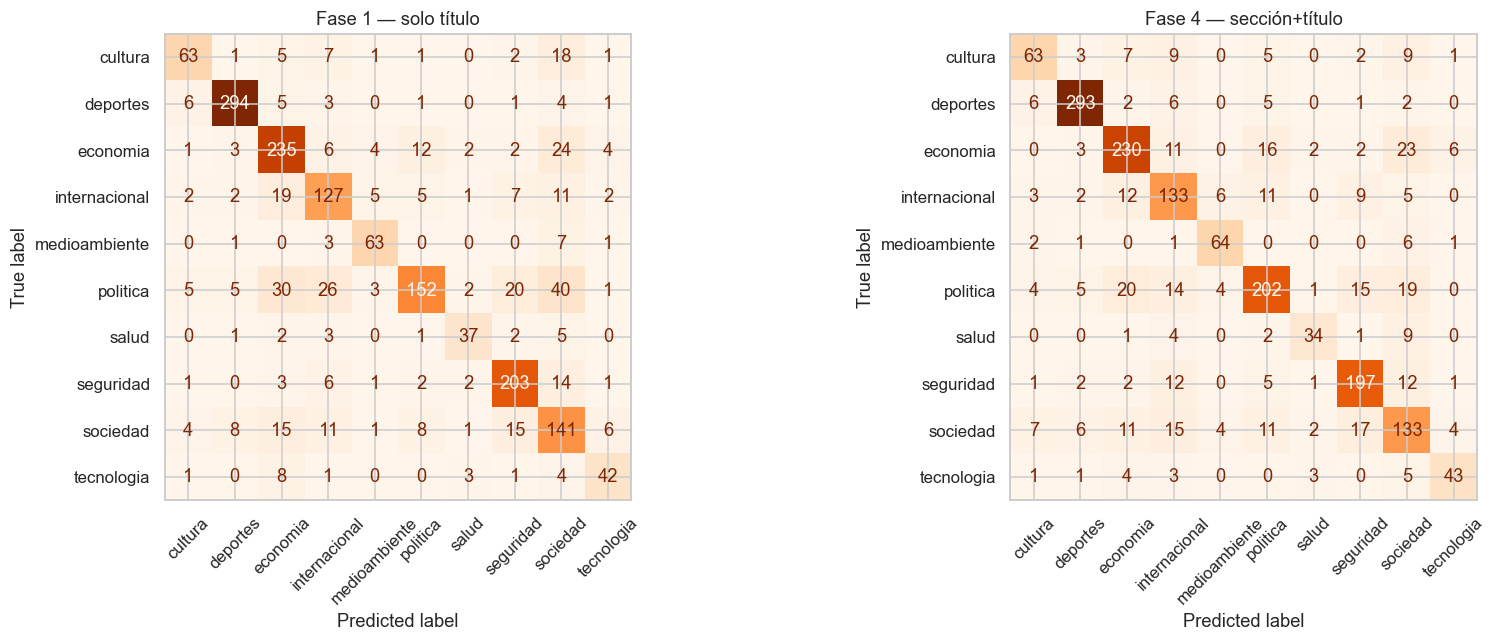

Pares más frecuentes — Fase 1:


,true_label,pred_label,count
44,politica,sociedad,40
39,politica,economia,30
40,politica,internacional,26
22,economia,sociedad,24
43,politica,seguridad,20
26,internacional,economia,19
6,cultura,sociedad,18
67,sociedad,seguridad,15



Pares más frecuentes — Fase 4:


,true_label,pred_label,count
18,economia,sociedad,23
34,politica,economia,20
39,politica,sociedad,19
60,sociedad,seguridad,17
15,economia,politica,16
56,sociedad,internacional,15
38,politica,seguridad,15
35,politica,internacional,14


In [8]:
# Pares de confusión: baseline vs fase 4
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = sorted(temas_phase4["true_label"].unique())

for ax, (title, frame) in zip(
    axes,
    [("Fase 1 — solo título", temas_baseline), ("Fase 4 — sección+título", temas_phase4)],
):
    cm = confusion_matrix(frame["true_label"], frame["pred_label"], labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Oranges", xticks_rotation=45, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

print("Pares más frecuentes — Fase 1:")
display(top_confusion_pairs(temas_baseline))
print("\nPares más frecuentes — Fase 4:")
display(top_confusion_pairs(temas_phase4))


## Check 5 — Regresión por clase (F1 por tema)

In [9]:
def per_class_from_metrics(model_dir: Path) -> pd.DataFrame:
    metrics_path = model_dir / "metrics.json"
    payload = json.loads(metrics_path.read_text(encoding="utf-8"))
    report = payload.get("classification_report", {})
    rows = []
    for label, scores in report.items():
        if label in ("accuracy", "macro avg", "weighted avg"):
            continue
        rows.append(
            {
                "label": label,
                "f1": scores["f1-score"],
                "precision": scores["precision"],
                "recall": scores["recall"],
                "support": scores["support"],
            }
        )
    out = pd.DataFrame(rows)
    test_f1 = payload.get("test_metrics", {}).get("test_f1_macro")
    out.attrs["test_f1_macro"] = test_f1
    out.attrs["input_text_mode"] = payload.get("input_text_mode", "titulo")
    return out


f1_baseline = per_class_from_metrics(BASELINE_TEMAS)
f1_phase4 = per_class_from_metrics(FINAL_MODELS["temas"])

compare = f1_baseline[["label", "f1", "support"]].merge(
    f1_phase4[["label", "f1"]],
    on="label",
    suffixes=("_f1", "_f4"),
)
compare["delta_f1"] = compare["f1_f4"] - compare["f1_f1"]
compare = compare.sort_values("delta_f1")

print(
    f"Test F1 macro — Fase 1: {f1_baseline.attrs.get('test_f1_macro', 0):.3f} | "
    f"Fase 4: {f1_phase4.attrs.get('test_f1_macro', 0):.3f} | "
    f"Δ: {compare['delta_f1'].mean():+.3f} (promedio por clase)"
)
compare


Test F1 macro — Fase 1: 0.742 | Fase 4: 0.757 | Δ: +0.015 (promedio por clase)


,label,f1_f1,support,f1_f4,delta_f1
8,internacional,0.688822,181.0,0.683805,-0.005017
3,salud,0.727273,51.0,0.723404,-0.003868
4,deportes,0.928458,315.0,0.928685,0.000227
7,medioambiente,0.832298,75.0,0.836601,0.004303
6,tecnologia,0.736000,60.0,0.741379,0.005379
5,cultura,0.666667,99.0,0.677419,0.010753
1,seguridad,0.809619,233.0,0.825996,0.016377
9,sociedad,0.589744,210.0,0.614319,0.024575
2,economia,0.755337,293.0,0.790378,0.035041
0,politica,0.686747,284.0,0.746765,0.060018


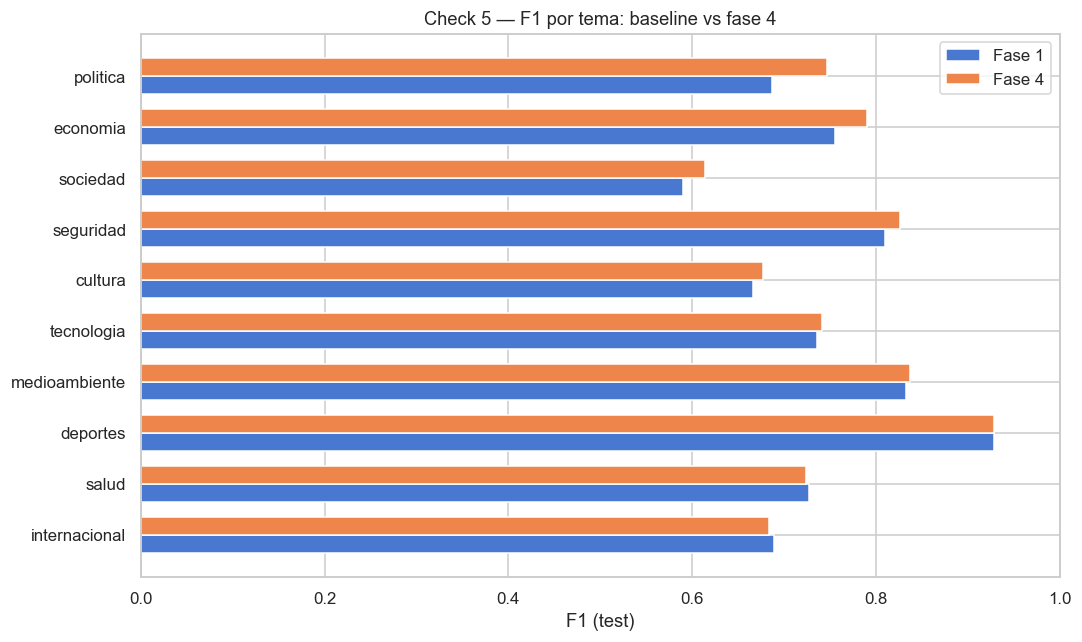

Clases mejoradas: 8 | regresadas: 2 | sin cambio: 0

Regresiones (F1 bajó):


,label,f1_f1,f1_f4,delta_f1,support
8,internacional,0.688822,0.683805,-0.005017,181.0
3,salud,0.727273,0.723404,-0.003868,51.0


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(compare))
width = 0.35
ax.barh([y - width / 2 for y in y_pos], compare["f1_f1"], height=width, label="Fase 1")
ax.barh([y + width / 2 for y in y_pos], compare["f1_f4"], height=width, label="Fase 4")
ax.set_yticks(list(y_pos), compare["label"])
ax.set_xlim(0, 1)
ax.set_xlabel("F1 (test)")
ax.set_title("Check 5 — F1 por tema: baseline vs fase 4")
ax.legend()
plt.tight_layout()
plt.show()

regressed = compare[compare["delta_f1"] < 0]
improved = compare[compare["delta_f1"] > 0]
print(f"Clases mejoradas: {len(improved)} | regresadas: {len(regressed)} | sin cambio: {len(compare) - len(improved) - len(regressed)}")
if not regressed.empty:
    print("\nRegresiones (F1 bajó):")
    display(regressed[["label", "f1_f1", "f1_f4", "delta_f1", "support"]])


In [11]:
# Verificación cruzada: F1 por clase desde predicciones (debe coincidir ~con metrics.json)
for label, frame in [("baseline", temas_baseline), ("phase4", temas_phase4)]:
    scores = f1_score(frame["true_label"], frame["pred_label"], average=None, labels=sorted(frame["true_label"].unique()))
    print(f"{label} macro F1 (sklearn): {f1_score(frame['true_label'], frame['pred_label'], average='macro'):.3f}")


baseline macro F1 (sklearn): 0.742
phase4 macro F1 (sklearn): 0.757
